# `align_apd_alternate_spin` — spin-up / spin-down voltage stability

Analysis for `kexp/experiments/HF_experiments/feedback/tools/align_apd_alternate_spin.py`.

**What the experiment does per shot.** After a scope trigger it runs
`for i in range(5)`, and in each iteration takes an integrated imaging pulse
(`t_imaging_pulse`, APD slot 0), a Raman &pi; pulse, a second imaging pulse
(APD slot 1), and another Raman &pi; pulse. So the PD scope trace carries
**10 imaging pulses, alternating spin state**: even pulses (0, 2, 4, 6, 8) are
the state the atoms start in, odd pulses (1, 3, 5, 7, 9) are the flipped state.
After the loop the tweezers are dropped and one more pulse is taken into APD
slot 2 as a light-only reference — 10 ms later, so it usually falls outside the
scope record.

**What this notebook measures.**

1. **Per-shot (within-shot) variation** — how much the up and down voltages
   scatter across the pulses of a single shot, both raw and after removing the
   mean pulse-index profile (which is dominated by loss/heating from repeated
   imaging, not by noise). `START_AT_NTH_PULSE` drops the leading pulses, so
   the first pulse of the train can be excluded from every statistic.
2. **Across-shot variation** — up, down, and their contrast versus shot index,
   both **per pulse index** and for the **mean over the first `N_FIRST`
   pulses** (adjustable), plus a sweep of `N_FIRST` against the $1/\sqrt{N}$
   expectation for independent pulses.
3. **Scope vs APD cross-check** — the hardware-integrated APD readback against
   the numerically integrated scope trace for the same pulse.

> **Note on the APD readback.** `DataContainer.put_data(v, idx)` *overwrites*
> slot `idx`, and the experiment writes slots 0 and 1 inside the loop. The
> saved `ad.data.apd` therefore holds only the **last** iteration's up/down
> pair (plus the slot-2 reference) — one pair per shot, not five. The APD can
> only contribute to the across-shot analysis; within-shot scatter comes from
> the scope alone. To get all 10 APD readings, widen the container to
> `add_data_container(2*N + 1)` and write `idx=2*i` / `idx=2*i+1`.

In [81]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from waxa import atomdata

# ------------------------------------------------------------------ config
RUN_ID = 0                 # 0 -> most recent run

SCOPE_LABEL = 'PD'         # scope label set in the experiment's prepare()
SCOPE_CH    = 0            # channel index passed to scope.read_sweep([0])

N_PAIRS = 5                # the `for i in range(5)` loop in scan_kernel
EVEN_PULSE_SPIN = 'up'     # label for pulses 0, 2, 4, ... ('up' or 'down')

# Which pulses of each shot to analyse. START_AT_NTH_PULSE drops the leading
# pulses of every shot -- set it to 1 to skip the first up/down pair, whose
# atom number and imaging conditions differ from the rest of the train.
# Everything downstream (within-shot scatter, per-pulse-index trends, the
# first-N mean and its sweep) uses the retained pulses only.
START_AT_NTH_PULSE = 1     # <-- adjustable: 0-based index of the first pulse kept
N_FIRST = 3                # <-- adjustable: average over the first N *retained* pulses

# pulse finder (windows are found once on the shot-averaged trace).
# The threshold is set just above the noise floor, NOT as a fraction of the
# pulse height: the spin-down pulse is much dimmer than spin-up by design, and
# a peak-relative threshold silently drops it.
T_PULSE         = None        # None -> take ad.p.t_imaging_pulse
THRESHOLD_SIGMA = 8.0         # threshold at this many noise sigma above baseline
THRESHOLD_FLOOR = 0.05        # ... but never below this fraction of the peak height
T_PRE           = 1.0e-6      # window opens this long before the rising edge
T_POST          = 1.5e-6      # ... and closes this long after the pulse ends
WIDTH_RANGE     = (0.5, 1.6)  # keep pulses this wide, in units of T_PULSE.
                              # The upper bound also rejects the longer Raman
                              # pulses if they scatter onto the PD.
MERGE_GAP       = 1.0e-6      # bridge sub-threshold dips shorter than this

# APD container slots written by integrated_imaging_pulse(...)
APD_SLOT_EVEN = 0          # same spin state as the even scope pulses
APD_SLOT_ODD  = 1
APD_SLOT_REF  = 2          # light-only reference, tweezers off

RESHUFFLE_TO_ACQUISITION_ORDER = False  # True if the run has a real (shuffled) xvar

SPIN_EVEN = EVEN_PULSE_SPIN
SPIN_ODD  = 'down' if EVEN_PULSE_SPIN == 'up' else 'up'

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helpers

Pulse windows are located **once** on the shot-averaged trace and then applied
identically to every shot. Detecting edges per shot would let the edge finder's
own threshold noise leak into the pulse-to-pulse scatter we are trying to
measure; the ARTIQ timeline is deterministic, so one set of windows is right
for every shot.

In [82]:
def as_shot_axis(a):
    """Flatten every leading (xvar / repeat) axis into a single shot axis."""
    a = np.asarray(a)
    return a.reshape(-1, a.shape[-1])


def find_pulse_edges(v, threshold, min_width=1, merge_gap=0):
    """Index pairs (i0, i1) of contiguous runs where v > threshold."""
    above = np.asarray(v) > threshold
    d = np.diff(above.astype(np.int8))
    rise = list(np.flatnonzero(d == 1) + 1)
    fall = list(np.flatnonzero(d == -1) + 1)
    if above[0]:
        rise = [0] + rise
    if above[-1]:
        fall = fall + [len(above)]
    merged = []
    for a, b in zip(rise, fall):
        if merged and a - merged[-1][1] <= merge_gap:
            merged[-1] = (merged[-1][0], b)
        else:
            merged.append((a, b))
    return [(a, b) for a, b in merged if (b - a) >= min_width]


def find_pulse_windows(t, v_mean, t_pulse, threshold_sigma=THRESHOLD_SIGMA,
                       threshold_floor=THRESHOLD_FLOOR,
                       t_pre=T_PRE, t_post=T_POST, width_range=WIDTH_RANGE,
                       merge_gap_s=MERGE_GAP):
    """Locate the imaging pulses on a high-SNR (shot-averaged) trace.

    The threshold sits `threshold_sigma` robust noise sigma above the baseline,
    floored at `threshold_floor` of the peak height. It is deliberately *not* a
    fixed fraction of the peak: spin-down pulses are much dimmer than spin-up,
    and a peak-relative threshold drops them without any visible error.

    Returns (windows, info); each window is an (i0, i1) index pair spanning
    [rising edge - t_pre, rising edge + t_pulse + t_post]. Every window has the
    same length, so the integrals are directly comparable.
    """
    t = np.asarray(t, dtype=float)
    v_mean = np.asarray(v_mean, dtype=float)
    dt = float(np.median(np.diff(t)))

    baseline = float(np.percentile(v_mean, 20.0))
    amp = float(np.percentile(v_mean, 99.9)) - baseline
    # Robust noise: pulses occupy a small duty cycle, so the median and MAD of
    # the whole trace describe the baseline.
    med = float(np.median(v_mean))
    noise = 1.4826 * float(np.median(np.abs(v_mean - med)))
    thr = baseline + max(threshold_sigma * noise, threshold_floor * amp)

    # Every above-threshold run, before the width cut -- reported on failure so
    # a mismatched T_PULSE is obvious rather than showing up as "0 pulses".
    candidates = find_pulse_edges(v_mean, thr, min_width=1,
                                  merge_gap=int(round(merge_gap_s / dt)))
    n_min = max(1, int(round(width_range[0] * t_pulse / dt)))
    n_max = int(round(width_range[1] * t_pulse / dt))
    edges = [(a, b) for a, b in candidates if n_min <= (b - a) <= n_max]

    n_pre = int(round(t_pre / dt))
    n_win = int(round((t_pulse + t_pre + t_post) / dt))
    windows, starts, widths = [], [], []
    for a, b in edges:
        i0 = max(0, a - n_pre)
        i1 = i0 + n_win
        if i1 > len(t):            # pulse runs off the end of the record
            continue
        windows.append((i0, i1))
        starts.append(t[a])
        widths.append((b - a) * dt)

    info = dict(dt=dt, baseline=baseline, amp=amp, threshold=thr,
                noise=noise, n_win=n_win,
                t_start=np.array(starts), width=np.array(widths),
                candidate_start=np.array([t[a] for a, _ in candidates]),
                candidate_width=np.array([(b - a) * dt for a, b in candidates]))
    return windows, info


def window_mask(npts, windows, guard=0):
    """Boolean mask that is True *outside* every window (plus a guard band)."""
    m = np.ones(npts, dtype=bool)
    for i0, i1 in windows:
        m[max(0, i0 - guard):min(npts, i1 + guard)] = False
    return m


def integrate_windows(t, v, windows, baseline):
    """Integrate v - baseline over each window -> (n_shots, n_pulses), in V*s."""
    v = np.asarray(v, dtype=float)
    baseline = np.reshape(np.asarray(baseline, dtype=float), (-1, 1))
    dt = float(np.median(np.diff(np.asarray(t, dtype=float))))
    out = np.empty((v.shape[0], len(windows)), dtype=float)
    for k, (i0, i1) in enumerate(windows):
        out[:, k] = np.trapezoid(v[:, i0:i1] - baseline, dx=dt, axis=1)
    return out


def rel_std(x, axis=None):
    """Std as a fraction of the mean."""
    x = np.asarray(x, dtype=float)
    m = np.mean(x, axis=axis)
    s = np.std(x, axis=axis, ddof=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(np.abs(m) > 0, s / np.abs(m), np.nan)


def contrast(up, down):
    """(up - down) / (up + down) -- the s_z-like normalized spin signal."""
    up, down = np.asarray(up, float), np.asarray(down, float)
    with np.errstate(divide='ignore', invalid='ignore'):
        return (up - down) / (up + down)


def first_n_mean(x, n):
    """Mean over the first n pulses of an (n_shots, n_pulses) array."""
    return np.mean(np.asarray(x, float)[:, :int(n)], axis=1)


def detrend_by_pulse_index(x):
    """Remove the shot-averaged pulse-index profile.

    The signal decays across the pulses of a shot (imaging loss / heating),
    which is a reproducible trend, not noise. Subtracting the mean profile
    leaves the genuine within-shot scatter.
    """
    x = np.asarray(x, float)
    return x - x.mean(axis=0, keepdims=True) + x.mean()


def pct_str(x):
    """Relative std as a percentage, or 'n/a' when the mean is not resolved.

    A percentage of a mean that is consistent with zero (as the contrast is
    when the two spin states overlap) is a divide-by-noise, not a measurement.
    """
    rs = rel_std(np.asarray(x, float).ravel())
    return f'{100*rs:6.2f} %' if np.isfinite(rs) and rs < 1 else '   n/a  '


def summarize(name, x, unit=''):
    x = np.asarray(x, float).ravel()
    print(f'  {name:<34s} {np.mean(x):10.4f} +/- {np.std(x, ddof=1):8.4f} '
          f'{unit:<5s}  ({pct_str(x)})')

## Load the run

In [83]:
ad = atomdata(RUN_ID)
if RESHUFFLE_TO_ACQUISITION_ORDER:
    ad.reshuffle()      # shot index -> acquisition order

trace = ad.scope_data[SCOPE_LABEL][SCOPE_CH]
t = np.asarray(trace.t, dtype=float).reshape(-1, np.asarray(trace.t).shape[-1])[0]
V = as_shot_axis(trace.v).astype(float)
n_shots, n_pts = V.shape

t_pulse = float(ad.p.t_imaging_pulse) if T_PULSE is None else float(T_PULSE)

print(f'run {ad.run_info.run_id}   ({ad.run_info.run_datetime_str})')
print(f'  shots            {n_shots}')
print(f'  N_repeats        {int(ad.p.N_repeats)}')
print(f'  xvars            {list(ad.xvarnames)}')
print(f'  trace            {n_pts} pts, {t[0]*1e6:.1f} to {t[-1]*1e6:.1f} us, '
      f'dt = {np.median(np.diff(t))*1e9:.3f} ns')
print(f'  t_imaging_pulse  {t_pulse*1e6:.3f} us')
print(f'  t_raman_pi_pulse {float(ad.p.t_raman_pi_pulse)*1e6:.4f} us')
print(f'  amp_imaging      {float(ad.p.amp_imaging):.3f}')
print(f'  expected pulses  {2*N_PAIRS} in the loop (+1 reference, 10 ms later)')

76297
[atomdata timing] load total=0.791s | get_data_file(initial)=0.003s | h5_open=0.006s | headers=0.447s | core_arrays=0.319s | datavault=0.007s | scope_data=0.000s
No ROI saved in run 76297 (cached).
Specify the new ROI.
Auto-ROI suggests roix=[188, 211], roiy=[221, 244] (confidence 0.70).
[atomdata timing] analyze_ods total=0.113s | roi_crop=0.001s | sum_projections=0.000s | fit_x=0.056s | fit_y=0.055s | postfit=0.000s
[atomdata timing] initial_analysis total=0.461s | sort_images=0.017s | transpose=0.000s | compute_raw_ods=0.170s | avg_repeats=0.000s | analyze_ods=0.113s | refresh_repeat_stats=0.161s
[atomdata timing] init total=4.339s | load_data=0.791s | setup+roi=3.087s | suggest_roi=0.033s | unshuffle_old=0.000s | initial_analysis=0.461s


KeyError: 'PD'

## Find the pulse windows

In [ ]:
v_mean = V.mean(axis=0)
windows_all, info = find_pulse_windows(t, v_mean, t_pulse)

n_expected = 2 * N_PAIRS
n_found = len(windows_all)
ref_window = windows_all[-1] if n_found == n_expected + 1 else None
ok = n_found in (n_expected, n_expected + 1)

print(f'  threshold  {info["threshold"]:.4f} V   '
      f'(baseline {info["baseline"]:.4f} V, peak {info["amp"]:.4f} V, '
      f'noise {info["noise"]:.5f} V)')
print(f'  window     {info["n_win"]} samples = '
      f'{info["n_win"]*info["dt"]*1e6:.3f} us')
print(f'  found      {n_found} pulses, expected {n_expected} '
      f'(or {n_expected+1} with the reference)\n')

print('   k  spin    start (us)   width (us)   spacing (us)')
for k in range(n_found):
    spacing = (info['t_start'][k] - info['t_start'][k-1]) * 1e6 if k else np.nan
    is_ref = ref_window is not None and k == n_found - 1
    spin = '  ref' if is_ref else (SPIN_EVEN if k % 2 == 0 else SPIN_ODD)
    print(f'  {k:2d}  {spin:<6s} {info["t_start"][k]*1e6:10.3f} '
          f'{info["width"][k]*1e6:12.3f} {spacing:13.3f}')

if not ok:
    cw = info['candidate_width'] * 1e6
    print(f'\n*** Pulse count is wrong -- do not trust anything below until this '
          f'is fixed.')
    print(f'    {len(cw)} above-threshold features before the width cut '
          f'({WIDTH_RANGE[0]*t_pulse*1e6:.2f} to {WIDTH_RANGE[1]*t_pulse*1e6:.2f} us):')
    if len(cw):
        print(f'      widths (us): {np.round(np.sort(cw)[::-1][:20], 3)}')
        print(f'      median {np.median(cw):.3f} us vs T_PULSE = {t_pulse*1e6:.3f} us'
              f'  -> if these differ, set T_PULSE explicitly in the config cell.')
    print(f'    Otherwise tune THRESHOLD_SIGMA / WIDTH_RANGE / MERGE_GAP, or set '
          f'N_PAIRS\n    to match the loop count actually used for this run.')

  threshold  0.0435 V   (baseline -0.0327 V, peak 1.5232 V, noise 0.00815 V)
  window     15159 samples = 7.500 us
  found      10 pulses, expected 10 (or 11 with the reference)

   k  spin    start (us)   width (us)   spacing (us)
   0  up          2.276        6.318           nan
   1  down       34.646        5.553        32.370
   2  up         66.763        6.279        32.117
   3  down       99.183        5.369        32.421
   4  up        131.241        6.320        32.057
   5  down      163.705        5.258        32.464
   6  up        195.775        6.302        32.070
   7  down      228.162        5.389        32.387
   8  up        260.247        6.282        32.085
   9  down      292.643        5.472        32.396


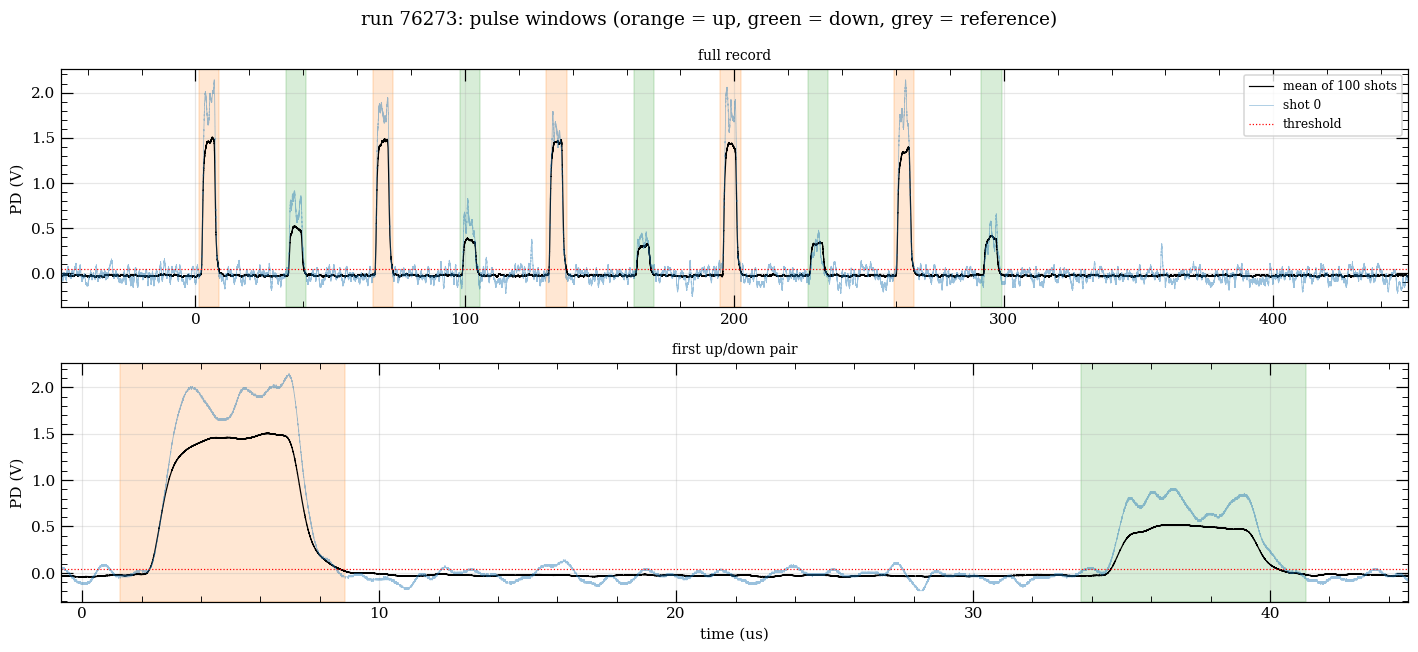

In [ ]:
# Diagnostic: shot-averaged trace with the integration windows shaded, and a
# zoom on the first up/down pair. If the shading does not sit squarely on the
# pulses, everything below is meaningless -- retune the finder first.
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

if n_found:
    zoom_lo = info['t_start'][0] - 3e-6
    zoom_hi = info['t_start'][min(1, n_found-1)] + t_pulse + 5e-6
else:                                   # nothing found: zoom on the record head
    zoom_lo, zoom_hi = t[0], t[0] + 0.1 * (t[-1] - t[0])

for ax, (lo, hi), ttl in [
        (axes[0], (t[0], t[-1]), 'full record'),
        (axes[1], (zoom_lo, zoom_hi), f'first {SPIN_EVEN}/{SPIN_ODD} pair')]:
    sel = (t >= lo) & (t <= hi)
    ax.plot(t[sel]*1e6, v_mean[sel], lw=0.8, color='k',
            label=f'mean of {n_shots} shots')
    ax.plot(t[sel]*1e6, V[0][sel], lw=0.5, alpha=0.45, color='C0', label='shot 0')
    for k, (i0, i1) in enumerate(windows_all):
        is_ref = ref_window is not None and k == len(windows_all) - 1
        c = '0.6' if is_ref else ('C1' if k % 2 == 0 else 'C2')
        ax.axvspan(t[i0]*1e6, t[i1-1]*1e6, color=c, alpha=0.18)
    ax.axhline(info['threshold'], color='r', ls=':', lw=0.8, label='threshold')
    ax.set_xlim(lo*1e6, hi*1e6)
    ax.set_ylabel('PD (V)')
    ax.set_title(ttl, fontsize=9)
axes[0].legend(fontsize=8, loc='upper right')
axes[1].set_xlabel('time (us)')
fig.suptitle(f'run {ad.run_info.run_id}: pulse windows '
             f'(orange = {SPIN_EVEN}, green = {SPIN_ODD}, grey = reference)')
fig.tight_layout()

Check the shading above before going on. The next cell refuses to continue on a
wrong pulse count — analysing mis-assigned windows would silently mix the two
spin states together.

In [ ]:
if not ok:
    raise RuntimeError(
        f'Pulse finder returned {n_found} pulses, expected {n_expected} or '
        f'{n_expected+1}. Retune the finder in the config cell (see the '
        f'diagnostic above); the analysis below assumes alternating '
        f'{SPIN_EVEN}/{SPIN_ODD} pulses.')

windows = windows_all[:-1] if ref_window is not None else windows_all
n_pulses = len(windows)
n_pairs_all = n_pulses // 2

print(f'{n_pulses} loop pulses -> {n_pairs_all} {SPIN_EVEN}/{SPIN_ODD} pairs per shot; '
      f'reference pulse {"in" if ref_window is not None else "not in"} the record.')

10 loop pulses -> 5 up/down pairs per shot; reference pulse not in the record.


## Integrate the scope trace and pull out the APD readback

The per-shot baseline is the median of everything *outside* the windows (with a
guard band), so a slow PD offset drift cannot masquerade as signal drift.

In [ ]:
guard = info['n_win']
bmask = window_mask(n_pts, windows_all, guard=guard)
baseline_shot = np.median(V[:, bmask], axis=1)

S = integrate_windows(t, V, windows, baseline_shot) * 1e6   # V*us

# Full pulse trains, one column per loop iteration. Kept intact so the decay
# profile below can show the pulses that START_AT_NTH_PULSE excludes, and so the
# APD cross-check can always reach the genuine last pulse.
S_even_all = S[:, 0::2][:, :n_pairs_all]      # spin SPIN_EVEN
S_odd_all  = S[:, 1::2][:, :n_pairs_all]      # spin SPIN_ODD

# ... and the retained slice everything downstream analyses.
P0 = int(START_AT_NTH_PULSE)
assert 0 <= P0 < n_pairs_all, f'START_AT_NTH_PULSE must be in 0..{n_pairs_all-1}'
S_even, S_odd = S_even_all[:, P0:], S_odd_all[:, P0:]
n_pairs = S_even.shape[1]
pulse_idx = np.arange(P0, n_pairs_all)        # original index of each retained pulse

# Within-shot scatter needs at least two retained pulses to be defined at all.
WITHIN_OK = n_pairs >= 2

S_ref = None
if ref_window is not None:
    S_ref = integrate_windows(t, V, [ref_window], baseline_shot)[:, 0] * 1e6

# --- APD readback (one up/down pair per shot: the LAST loop iteration) -------
apd = np.asarray(ad.data.apd, float)
apd = apd.reshape(-1, apd.shape[-1])
apd_even, apd_odd = apd[:, APD_SLOT_EVEN], apd[:, APD_SLOT_ODD]
apd_ref = apd[:, APD_SLOT_REF] if apd.shape[1] > APD_SLOT_REF else None

print(f'scope integrals S: {S.shape}  (shots x pulses), units V*us')
print(f'  baseline per shot: {baseline_shot.mean():.4f} +/- '
      f'{baseline_shot.std(ddof=1):.4f} V')
if P0:
    print(f'  START_AT_NTH_PULSE = {P0}: analysing pulses {P0}..{n_pairs_all-1} '
          f'({n_pairs} of {n_pairs_all} pairs); the first {P0} skipped.')
else:
    print(f'  START_AT_NTH_PULSE = 0: analysing all {n_pairs_all} pairs.')
if not WITHIN_OK:
    print(f'  *** only {n_pairs} pulse pair retained -- within-shot scatter needs '
          f'at least 2.\n      Part 1 is skipped; lower START_AT_NTH_PULSE to '
          f'get it back. The across-shot\n      sections below still work.')
print()
print(f'APD readback: {apd.shape}  (shots x container slots)')
print(f'  slot {APD_SLOT_EVEN} ({SPIN_EVEN}) and slot {APD_SLOT_ODD} ({SPIN_ODD}) '
      f'hold loop iteration {n_pairs_all-1} only (put_data overwrites).')
if apd_ref is not None:
    print(f'  slot {APD_SLOT_REF} (reference, tweezers off): '
          f'{apd_ref.mean():.4f} +/- {apd_ref.std(ddof=1):.4f} V')

scope integrals S: (100, 10)  (shots x pulses), units V*us
  baseline per shot: -0.0288 +/- 0.0074 V
  START_AT_NTH_PULSE = 1: analysing pulses 1..4 (4 of 5 pairs); the first 1 skipped.

APD readback: (100, 3)  (shots x container slots)
  slot 0 (up) and slot 1 (down) hold loop iteration 4 only (put_data overwrites).
  slot 2 (reference, tweezers off): -0.1687 +/- 0.0072 V


## 1. Per-shot (within-shot) variation

How much do the `N_PAIRS` up pulses of a *single* shot scatter, and likewise
the down pulses?

Two numbers per shot are reported, and the difference between them matters:

* **raw** — `std` over the pulses of that shot. Includes the systematic decay
  with pulse index (atoms lost / heated by earlier imaging pulses), so it
  overstates the noise.
* **detrended** — the same after subtracting the shot-averaged pulse-index
  profile. This is the genuine per-shot pulse-to-pulse noise.

Set `START_AT_NTH_PULSE = 1` in the config cell to drop the first up/down pair
(and `= 2` for the first two, and so on). The excluded pulses stay visible,
shaded, in the profile plots below, so it is easy to see whether skipping them
was warranted; every statistic uses the retained pulses only.

The APD cannot contribute here: it stores only the last iteration's pair.

In [ ]:
S_even_dt = detrend_by_pulse_index(S_even)
S_odd_dt  = detrend_by_pulse_index(S_odd)

C_pair = contrast(S_even, S_odd)          # (shots, pairs)
D_pair = S_even - S_odd

within = {
    f'{SPIN_EVEN} raw':       (np.std(S_even,    axis=1, ddof=1), S_even, 'V*us'),
    f'{SPIN_ODD} raw':        (np.std(S_odd,     axis=1, ddof=1), S_odd,  'V*us'),
    f'{SPIN_EVEN} detrended': (np.std(S_even_dt, axis=1, ddof=1), S_even, 'V*us'),
    f'{SPIN_ODD} detrended':  (np.std(S_odd_dt,  axis=1, ddof=1), S_odd,  'V*us'),
    'contrast raw':           (np.std(C_pair,    axis=1, ddof=1), C_pair, ''),
    'contrast detrended':     (np.std(detrend_by_pulse_index(C_pair),
                                      axis=1, ddof=1),            C_pair, ''),
}

if not WITHIN_OK:
    print(f'Within-shot scatter is undefined with {n_pairs} retained pulse pair '
          f'(START_AT_NTH_PULSE = {P0}).\nLower it to 0..{n_pairs_all-2} to '
          f'measure it. Skipping to the across-shot sections.')

print(f'Within-shot scatter over pulses {pulse_idx[0]}..{pulse_idx[-1]} '
      f'({n_pairs} of {n_pairs_all}) of each spin state, '
      f'averaged over {n_shots} shots:\n') if WITHIN_OK else None
print(f'  {"quantity":<22s} {"mean std":>10s}         {"as % of mean":>12s}')
for key, (arr, base, unit) in (within.items() if WITHIN_OK else []):
    m = abs(base.mean())
    frac = arr.mean() / m if m > 0 else np.inf
    pct = f'{100*frac:10.2f} %' if frac < 1 else '       n/a  '
    print(f'  {key:<22s} {arr.mean():10.4f} {unit:<7s} {pct}')

print(f'\n  APD within-shot scatter: not available -- only loop iteration '
      f'{n_pairs_all-1} is stored (see the note at the top).')

Within-shot scatter over pulses 1..4 (4 of 5) of each spin state, averaged over 100 shots:

  quantity                 mean std         as % of mean
  up raw                     0.5495 V*us          8.10 %
  down raw                   0.4815 V*us         27.14 %
  up detrended               0.4946 V*us          7.29 %
  down detrended             0.4496 V*us         25.34 %
  contrast raw               0.0894              15.13 %
  contrast detrended         0.0784              13.27 %

  APD within-shot scatter: not available -- only loop iteration 4 is stored (see the note at the top).


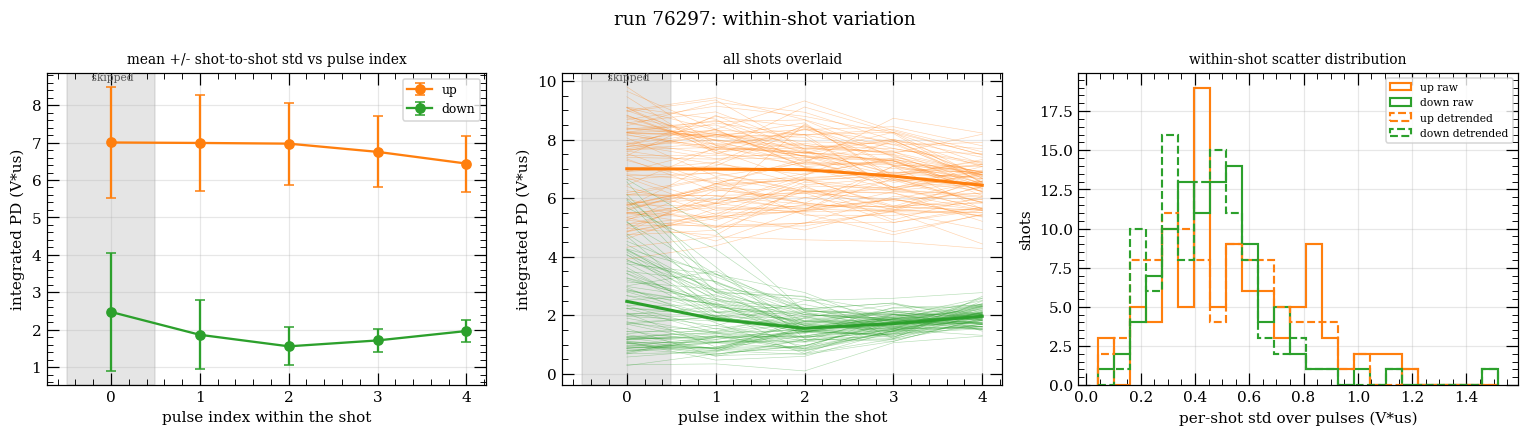

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) mean +/- shot-to-shot spread versus pulse index -- the decay profile.
# The full train is drawn, with the pulses START_AT_NTH_PULSE excludes shaded,
# so it stays visible whether skipping them was justified.
k_all = np.arange(n_pairs_all)
k = pulse_idx
for arr, lbl, c in [(S_even_all, SPIN_EVEN, 'C1'), (S_odd_all, SPIN_ODD, 'C2')]:
    axes[0].errorbar(k_all, arr.mean(0), yerr=arr.std(0, ddof=1), marker='o',
                     capsize=3, color=c, label=lbl)
axes[0].set_xlabel('pulse index within the shot')
axes[0].set_ylabel('integrated PD (V*us)')
axes[0].set_title('mean +/- shot-to-shot std vs pulse index', fontsize=9)
axes[0].set_xticks(k_all)
axes[0].legend(fontsize=8)

# (b) every shot's pulse train, thin, to expose outlier shots
for arr, c in [(S_even_all, 'C1'), (S_odd_all, 'C2')]:
    axes[1].plot(k_all, arr.T, color=c, lw=0.4, alpha=0.35)
    axes[1].plot(k_all, arr.mean(0), color=c, lw=2)
axes[1].set_xlabel('pulse index within the shot')
axes[1].set_ylabel('integrated PD (V*us)')
axes[1].set_title('all shots overlaid', fontsize=9)
axes[1].set_xticks(k_all)

for ax in axes[:2]:                       # grey out the excluded pulses
    if P0:
        ax.axvspan(-0.5, P0 - 0.5, color='0.5', alpha=0.20, zorder=0)
        ax.text(P0/2 - 0.5, ax.get_ylim()[1], ' skipped', ha='center',
                va='top', fontsize=7, color='0.35')

# (c) distribution of the per-shot scatter, raw vs detrended
if WITHIN_OK:
    bins = np.histogram_bin_edges(np.concatenate(
        [within[f'{SPIN_EVEN} raw'][0], within[f'{SPIN_ODD} raw'][0]]), 25)
    for key, c, ls in [(f'{SPIN_EVEN} raw', 'C1', '-'),
                       (f'{SPIN_ODD} raw', 'C2', '-'),
                       (f'{SPIN_EVEN} detrended', 'C1', '--'),
                       (f'{SPIN_ODD} detrended', 'C2', '--')]:
        axes[2].hist(within[key][0], bins=bins, histtype='step', color=c, ls=ls,
                     lw=1.4, label=key)
    axes[2].legend(fontsize=7)
else:
    axes[2].text(0.5, 0.5, f'needs >= 2 retained pulses\n(START_AT_NTH_PULSE = {P0})',
                 ha='center', va='center', fontsize=8, color='0.4',
                 transform=axes[2].transAxes)
axes[2].set_xlabel('per-shot std over pulses (V*us)')
axes[2].set_ylabel('shots')
axes[2].set_title('within-shot scatter distribution', fontsize=9)

fig.suptitle(f'run {ad.run_info.run_id}: within-shot variation')
fig.tight_layout()

### Up vs down, pulse by pulse

The quantity the APD alignment actually cares about is the *separation* between
the two spin states and how reproducible it is.

  mean difference      5.0141 V*us (within-shot std 0.6801, shot-to-shot std of the shot mean 0.7152)
  mean contrast        0.5911      (within-shot std 0.0894, shot-to-shot std of the shot mean 0.0534)


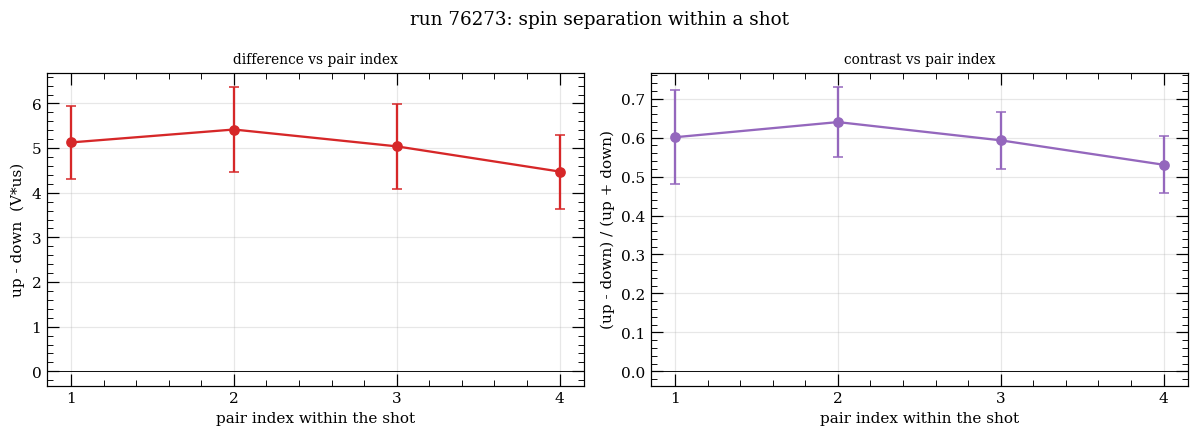

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(k, D_pair.mean(0), yerr=D_pair.std(0, ddof=1),
                 marker='o', capsize=3, color='C3')
axes[0].axhline(0, color='k', lw=0.6)
axes[0].set_xlabel('pair index within the shot')
axes[0].set_ylabel(f'{SPIN_EVEN} - {SPIN_ODD}  (V*us)')
axes[0].set_title('difference vs pair index', fontsize=9)
axes[0].set_xticks(k)

axes[1].errorbar(k, C_pair.mean(0), yerr=C_pair.std(0, ddof=1),
                 marker='o', capsize=3, color='C4')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xlabel('pair index within the shot')
axes[1].set_ylabel(f'({SPIN_EVEN} - {SPIN_ODD}) / ({SPIN_EVEN} + {SPIN_ODD})')
axes[1].set_title('contrast vs pair index', fontsize=9)
axes[1].set_xticks(k)

fig.suptitle(f'run {ad.run_info.run_id}: spin separation within a shot')
fig.tight_layout()

def _within(a):
    return f'{np.std(a, axis=1, ddof=1).mean():.4f}' if WITHIN_OK else 'n/a'

print(f'  mean difference  {D_pair.mean():10.4f} V*us '
      f'(within-shot std {_within(D_pair)}, '
      f'shot-to-shot std of the shot mean {D_pair.mean(1).std(ddof=1):.4f})')
print(f'  mean contrast    {C_pair.mean():10.4f}      '
      f'(within-shot std {_within(C_pair)}, '
      f'shot-to-shot std of the shot mean {C_pair.mean(1).std(ddof=1):.4f})')

### Across-shot mean and std vs pulse index

The same numbers as panel (a) above, but with the mean and the scatter on
separate axes: error bars hide how the *noise* itself grows along the train,
which is what a slow drift in imaging or trap depth shows up as. The full
train is drawn, with the pulses `START_AT_NTH_PULSE` excludes shaded.

  pulse        up mean       std       %    down mean       std       %   kept
  0             7.0027    1.4861   21.22       2.4743    1.5766   63.72   no
  1             6.9904    1.2927   18.49       1.8636    0.9255   49.66   yes
  2             6.9717    1.0943   15.70       1.5556    0.5081   32.66   yes
  3             6.7520    0.9511   14.09       1.7132    0.3181   18.57   yes
  4             6.4392    0.7479   11.62       1.9647    0.3054   15.55   yes


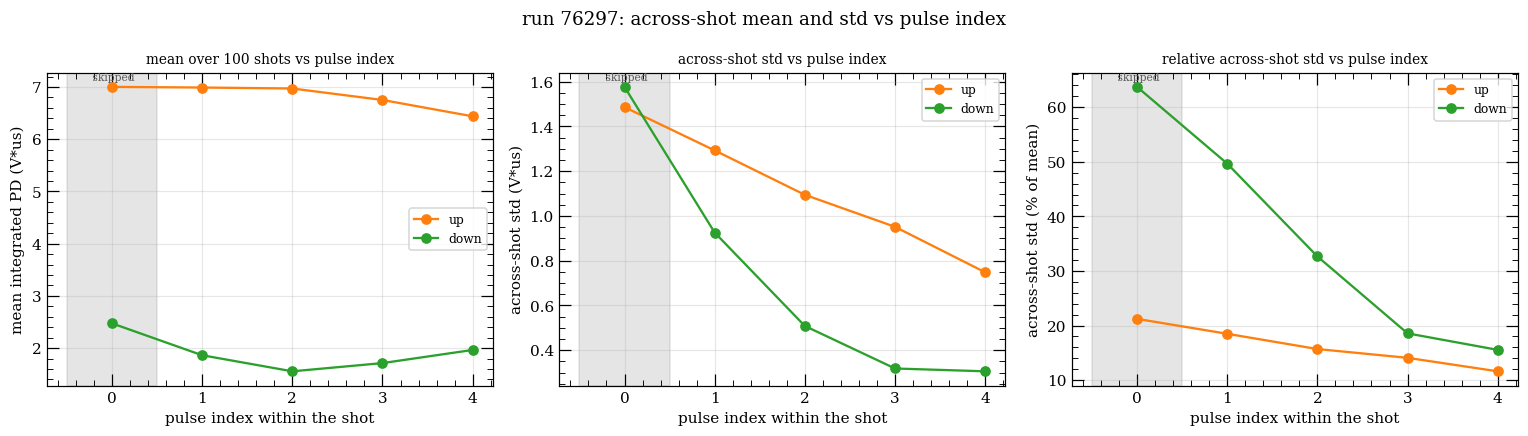

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

series = [(S_even_all, SPIN_EVEN, 'C1'), (S_odd_all, SPIN_ODD, 'C2')]

# (a) mean across shots
for arr, spin, c in series:
    axes[0].plot(k_all, arr.mean(0), marker='o', color=c, label=spin)
axes[0].set_ylabel('mean integrated PD (V*us)')
axes[0].set_title(f'mean over {n_shots} shots vs pulse index', fontsize=9)
axes[0].legend(fontsize=8)

# (b) across-shot std, absolute -- the shot-to-shot noise on a single pulse
for arr, spin, c in series:
    axes[1].plot(k_all, arr.std(0, ddof=1), marker='o', color=c, label=spin)
axes[1].set_ylabel('across-shot std (V*us)')
axes[1].set_title('across-shot std vs pulse index', fontsize=9)
axes[1].legend(fontsize=8)

# (c) ... and relative, so up and down are comparable despite their different
# brightness. A flat curve here means the noise is multiplicative (intensity /
# atom-number fluctuations); a rising one means it is not.
for arr, spin, c in series:
    axes[2].plot(k_all, 100*rel_std(arr, axis=0), marker='o', color=c, label=spin)
axes[2].set_ylabel('across-shot std (% of mean)')
axes[2].set_title('relative across-shot std vs pulse index', fontsize=9)
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('pulse index within the shot')
    ax.set_xticks(k_all)
    if P0:
        ax.axvspan(-0.5, P0 - 0.5, color='0.5', alpha=0.20, zorder=0)
        ax.text(P0/2 - 0.5, ax.get_ylim()[1], ' skipped', ha='center',
                va='top', fontsize=7, color='0.35')

fig.suptitle(f'run {ad.run_info.run_id}: across-shot mean and std vs pulse index')
fig.tight_layout()

print(f'  {"pulse":<7s}{SPIN_EVEN + " mean":>13s}{"std":>10s}{"%":>8s}'
      f'{SPIN_ODD + " mean":>13s}{"std":>10s}{"%":>8s}   kept')
for j in range(n_pairs_all):
    print(f'  {j:<7d}{S_even_all[:, j].mean():13.4f}'
          f'{S_even_all[:, j].std(ddof=1):10.4f}{100*rel_std(S_even_all[:, j]):8.2f}'
          f'{S_odd_all[:, j].mean():13.4f}'
          f'{S_odd_all[:, j].std(ddof=1):10.4f}{100*rel_std(S_odd_all[:, j]):8.2f}'
          f'   {"yes" if j >= P0 else "no"}')

## 2. Across-shot variation

### 2a. Per pulse index

Each pulse index is tracked separately across shots, so a drift that only
affects the later pulses (e.g. progressive loss) stays distinguishable from one
that moves the whole shot.

  pulse         up mean       std       %     down mean       std       %
  1              6.9904    1.2927   18.49        1.8636    0.9255   49.66
  2              6.9717    1.0943   15.70        1.5556    0.5081   32.66
  3              6.7520    0.9511   14.09        1.7132    0.3181   18.57
  4              6.4392    0.7479   11.62        1.9647    0.3054   15.55


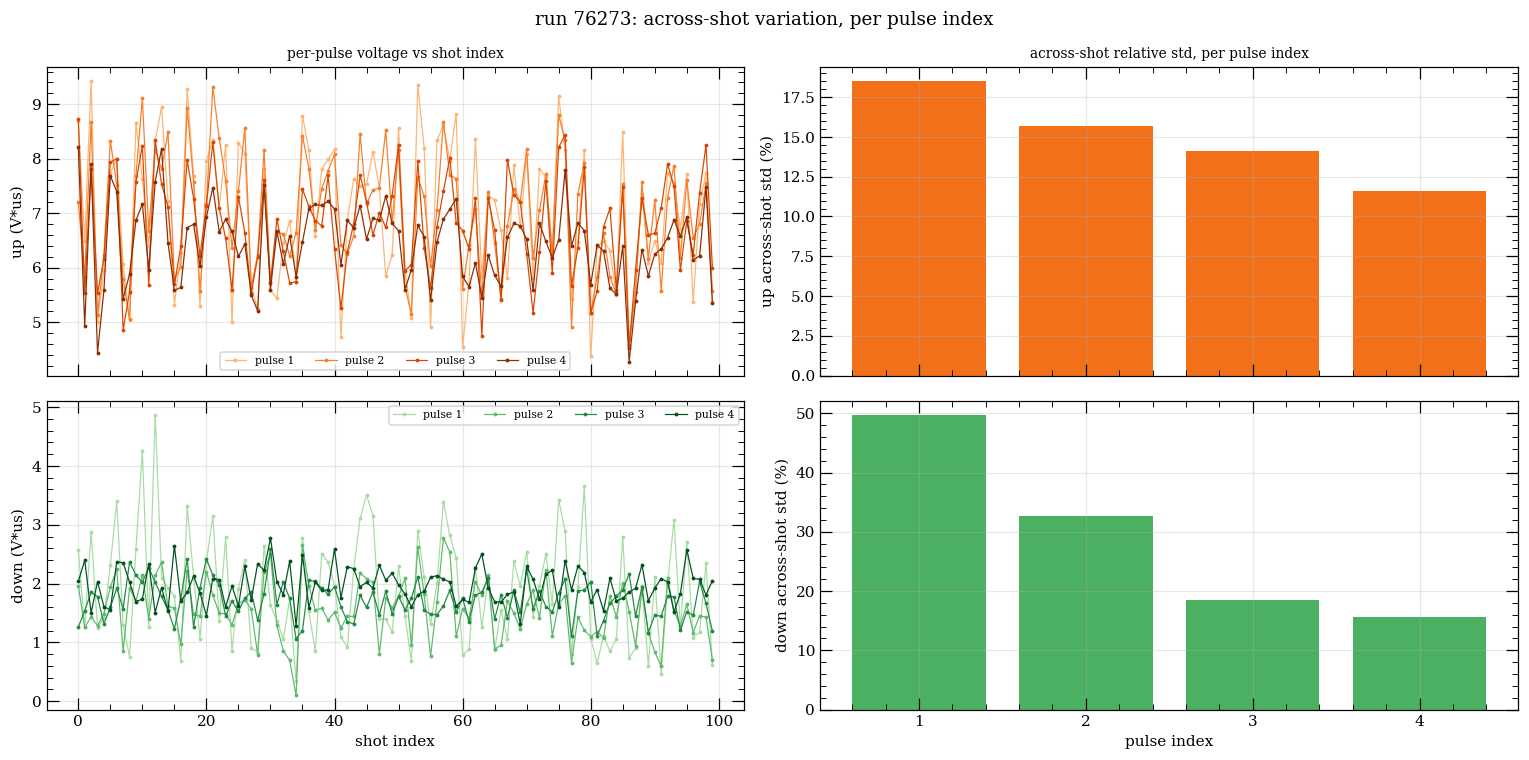

In [ ]:
shot = np.arange(n_shots)
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex='col')

for row, (arr, spin, cmap) in enumerate([(S_even, SPIN_EVEN, plt.cm.Oranges),
                                         (S_odd,  SPIN_ODD,  plt.cm.Greens)]):
    for j in range(n_pairs):
        axes[row, 0].plot(shot, arr[:, j], lw=0.8, marker='.', ms=3,
                          color=cmap(0.35 + 0.6*j/max(1, n_pairs-1)),
                          label=f'pulse {pulse_idx[j]}')
    axes[row, 0].set_ylabel(f'{spin} (V*us)')
    axes[row, 0].legend(fontsize=7, ncol=n_pairs)

    axes[row, 1].bar(pulse_idx, 100*rel_std(arr, axis=0), color=cmap(0.6))
    axes[row, 1].set_ylabel(f'{spin} across-shot std (%)')
    axes[row, 1].set_xticks(pulse_idx)

axes[1, 0].set_xlabel('shot index')
axes[1, 1].set_xlabel('pulse index')
axes[0, 0].set_title('per-pulse voltage vs shot index', fontsize=9)
axes[0, 1].set_title('across-shot relative std, per pulse index', fontsize=9)
fig.suptitle(f'run {ad.run_info.run_id}: across-shot variation, per pulse index')
fig.tight_layout()

print(f'  {"pulse":<7s}{SPIN_EVEN + " mean":>14s}{"std":>10s}{"%":>8s}'
      f'{SPIN_ODD + " mean":>14s}{"std":>10s}{"%":>8s}')
for j in range(n_pairs):
    print(f'  {pulse_idx[j]:<7d}{S_even[:, j].mean():14.4f}{S_even[:, j].std(ddof=1):10.4f}'
          f'{100*rel_std(S_even[:, j]):8.2f}'
          f'{S_odd[:, j].mean():14.4f}{S_odd[:, j].std(ddof=1):10.4f}'
          f'{100*rel_std(S_odd[:, j]):8.2f}')

### 2b. Mean over the first `N_FIRST` pulses

Averaging the first `N_FIRST` pulses of each shot is the natural per-shot
estimator: the earliest pulses are the least perturbed by prior imaging, and
averaging suppresses the per-pulse noise. `N_FIRST` counts from the first
*retained* pulse, so with `START_AT_NTH_PULSE = 1` and `N_FIRST = 3` it
averages pulses 1, 2 and 3. Change either in the config cell and re-run from
here.

Across 100 shots, mean over the first 3 retained pulses (pulses 1..3):
  up                                     6.9047 +/-   1.0268 V*us   ( 14.87 %)
  down                                   1.7108 +/-   0.4842 V*us   ( 28.30 %)
  up - down                              5.1939 +/-   0.7358 V*us   ( 14.17 %)
  contrast                               0.6081 +/-   0.0660        ( 10.85 %)


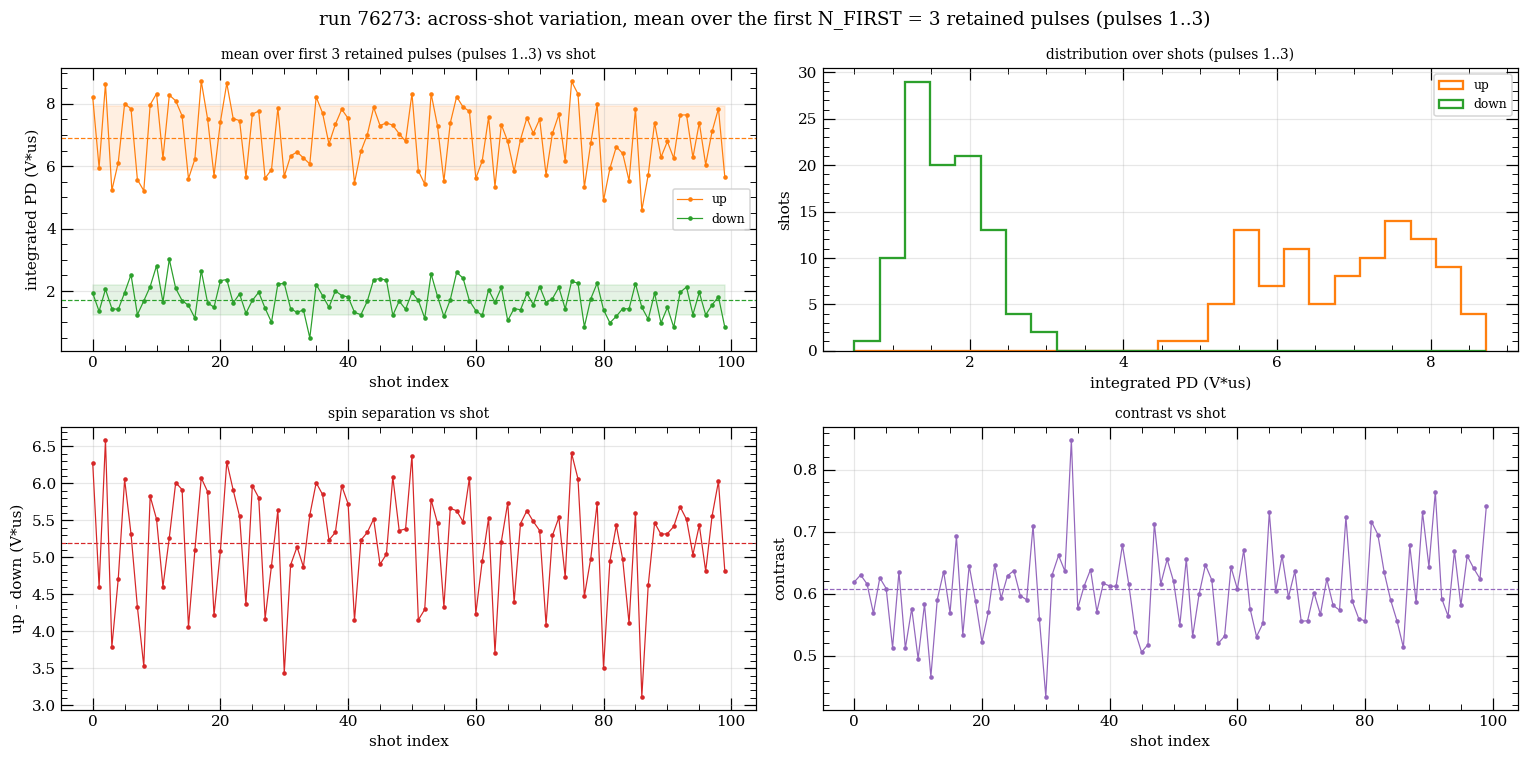

In [ ]:
N = int(N_FIRST)
assert 1 <= N <= n_pairs, (f'N_FIRST must be in 1..{n_pairs} -- only '
                           f'{n_pairs} pulses are retained after '
                           f'START_AT_NTH_PULSE = {P0}')
span = f'pulses {pulse_idx[0]}..{pulse_idx[N-1]}'

even_N = first_n_mean(S_even, N)
odd_N  = first_n_mean(S_odd,  N)
diff_N = even_N - odd_N
cont_N = contrast(even_N, odd_N)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

ax = axes[0, 0]
ax.plot(shot, even_N, '.-', lw=0.8, ms=4, color='C1', label=SPIN_EVEN)
ax.plot(shot, odd_N,  '.-', lw=0.8, ms=4, color='C2', label=SPIN_ODD)
for arr, c in [(even_N, 'C1'), (odd_N, 'C2')]:
    ax.axhline(arr.mean(), color=c, ls='--', lw=0.8)
    ax.fill_between(shot, arr.mean() - arr.std(ddof=1),
                    arr.mean() + arr.std(ddof=1), color=c, alpha=0.12)
ax.set_xlabel('shot index'); ax.set_ylabel('integrated PD (V*us)')
ax.set_title(f'mean over first {N} retained pulses ({span}) vs shot',
             fontsize=9)
ax.legend(fontsize=8)

ax = axes[0, 1]
bins = np.histogram_bin_edges(np.concatenate([even_N, odd_N]), 25)
ax.hist(even_N, bins=bins, histtype='step', lw=1.5, color='C1', label=SPIN_EVEN)
ax.hist(odd_N,  bins=bins, histtype='step', lw=1.5, color='C2', label=SPIN_ODD)
ax.set_xlabel('integrated PD (V*us)'); ax.set_ylabel('shots')
ax.set_title(f'distribution over shots ({span})', fontsize=9)
ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(shot, diff_N, '.-', lw=0.8, ms=4, color='C3')
ax.axhline(diff_N.mean(), color='C3', ls='--', lw=0.8)
ax.set_xlabel('shot index'); ax.set_ylabel(f'{SPIN_EVEN} - {SPIN_ODD} (V*us)')
ax.set_title('spin separation vs shot', fontsize=9)

ax = axes[1, 1]
ax.plot(shot, cont_N, '.-', lw=0.8, ms=4, color='C4')
ax.axhline(cont_N.mean(), color='C4', ls='--', lw=0.8)
ax.set_xlabel('shot index'); ax.set_ylabel('contrast')
ax.set_title('contrast vs shot', fontsize=9)

fig.suptitle(f'run {ad.run_info.run_id}: across-shot variation, '
             f'mean over the first N_FIRST = {N} retained pulses ({span})')
fig.tight_layout()

print(f'Across {n_shots} shots, mean over the first {N} retained pulses '
      f'({span}):')
summarize(f'{SPIN_EVEN}', even_N, 'V*us')
summarize(f'{SPIN_ODD}',  odd_N,  'V*us')
summarize(f'{SPIN_EVEN} - {SPIN_ODD}', diff_N, 'V*us')
summarize('contrast', cont_N)

### 2c. How the across-shot scatter falls with `N`

If the pulse-to-pulse noise were independent, the across-shot std of the
first-$N$ mean would fall as $1/\sqrt{N}$. A curve that flattens out early means
a common per-shot offset (atom number, alignment, imaging power) that averaging
over pulses cannot remove — which is the interesting failure mode for this
alignment tool.

    N       up std       %     down std       %    diff std   contrast std
    1       1.2927   18.49       0.9255   49.66      0.8203         0.1207
    2       1.1358   16.27       0.6482   37.91      0.7433         0.0874
    3       1.0268   14.87       0.4842   28.30      0.7358         0.0660
    4       0.9245   13.62       0.3765   21.22      0.7152         0.0534


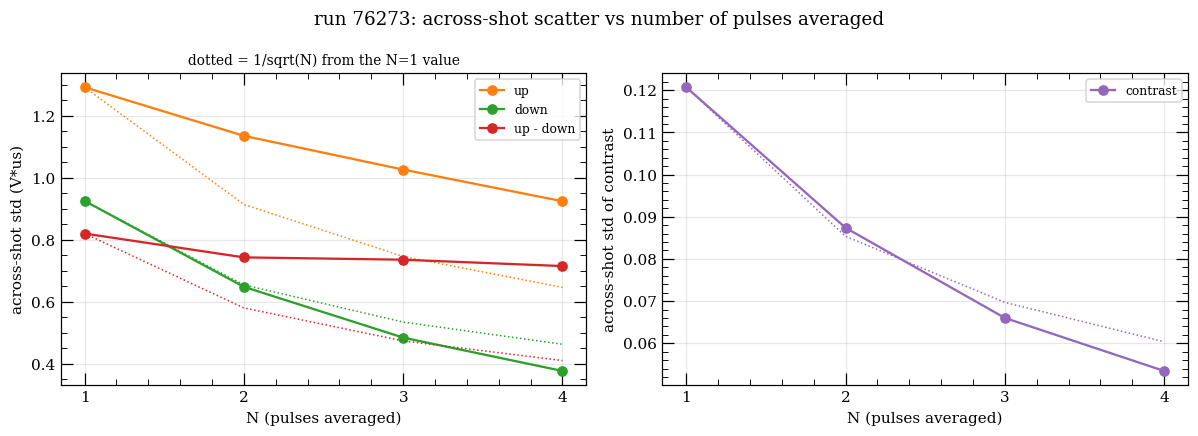

In [ ]:
Ns = np.arange(1, n_pairs + 1)
rows = []
for n in Ns:
    e, o = first_n_mean(S_even, n), first_n_mean(S_odd, n)
    rows.append((np.std(e, ddof=1), np.std(o, ddof=1),
                 np.std(e - o, ddof=1), np.std(contrast(e, o), ddof=1)))
sd_even, sd_odd, sd_diff, sd_cont = np.array(rows).T

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for sd, lbl, c in [(sd_even, SPIN_EVEN, 'C1'), (sd_odd, SPIN_ODD, 'C2'),
                   (sd_diff, f'{SPIN_EVEN} - {SPIN_ODD}', 'C3')]:
    axes[0].plot(Ns, sd, 'o-', color=c, label=lbl)
    axes[0].plot(Ns, sd[0] / np.sqrt(Ns), ':', color=c, lw=1)
axes[0].set_xlabel('N (pulses averaged)')
axes[0].set_ylabel('across-shot std (V*us)')
axes[0].set_title('dotted = 1/sqrt(N) from the N=1 value', fontsize=9)
axes[0].set_xticks(Ns); axes[0].legend(fontsize=8)

axes[1].plot(Ns, sd_cont, 'o-', color='C4', label='contrast')
axes[1].plot(Ns, sd_cont[0] / np.sqrt(Ns), ':', color='C4', lw=1)
axes[1].set_xlabel('N (pulses averaged)')
axes[1].set_ylabel('across-shot std of contrast')
axes[1].set_xticks(Ns); axes[1].legend(fontsize=8)

fig.suptitle(f'run {ad.run_info.run_id}: across-shot scatter vs number of '
             f'pulses averaged')
fig.tight_layout()

print(f'  {"N":>3s}{SPIN_EVEN + " std":>13s}{"%":>8s}{SPIN_ODD + " std":>13s}'
      f'{"%":>8s}{"diff std":>12s}{"contrast std":>15s}')
for i, n in enumerate(Ns):
    e, o = first_n_mean(S_even, n), first_n_mean(S_odd, n)
    print(f'  {n:>3d}{sd_even[i]:13.4f}{100*sd_even[i]/abs(e.mean()):8.2f}'
          f'{sd_odd[i]:13.4f}{100*sd_odd[i]/abs(o.mean()):8.2f}'
          f'{sd_diff[i]:12.4f}{sd_cont[i]:15.4f}')

### 2d. The APD readback across shots

One up/down pair per shot, from loop iteration `N_PAIRS - 1`. Plotted next to
the scope integral of the *same* pulse so the two either agree or visibly do
not.

Across 100 shots (APD, loop iteration 4):
  APD up                                -0.1216 +/-   0.0120 V      (  9.84 %)
  APD down                              -0.1945 +/-   0.0059 V      (  3.01 %)
  APD up - down                          0.0729 +/-   0.0139 V      ( 19.12 %)
  APD contrast                          -0.2321 +/-   0.0503        ( 21.68 %)
  APD reference (tweezers off)          -0.1687 +/-   0.0072 V      (  4.26 %)


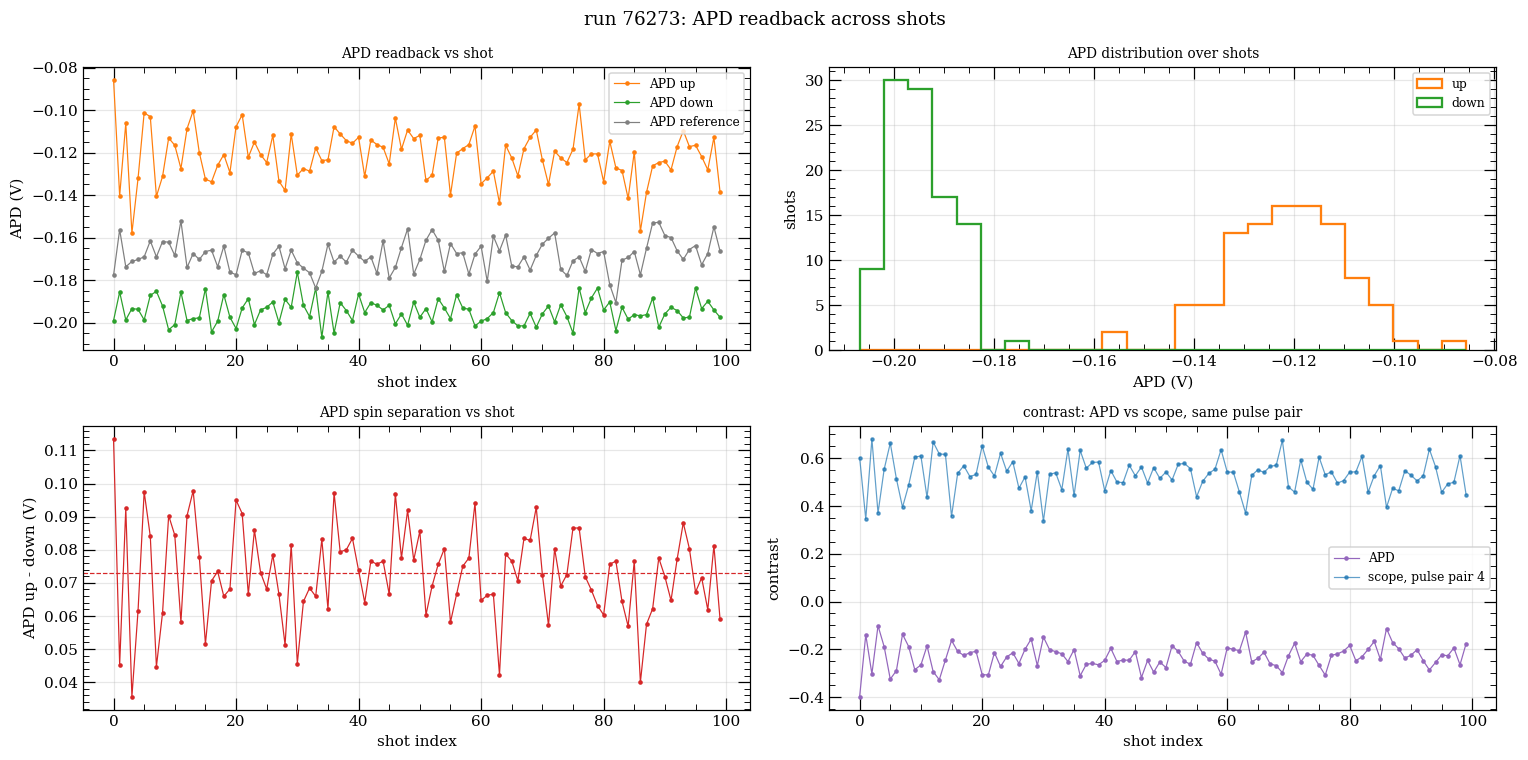

In [ ]:
# The APD stores loop iteration n_pairs_all-1, so compare against the full
# train's last pulse -- START_AT_NTH_PULSE must not move this.
last_even = S_even_all[:, -1]
last_odd  = S_odd_all[:, -1]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

ax = axes[0, 0]
ax.plot(shot, apd_even, '.-', lw=0.8, ms=4, color='C1', label=f'APD {SPIN_EVEN}')
ax.plot(shot, apd_odd,  '.-', lw=0.8, ms=4, color='C2', label=f'APD {SPIN_ODD}')
if apd_ref is not None:
    ax.plot(shot, apd_ref, '.-', lw=0.8, ms=4, color='0.5', label='APD reference')
ax.set_xlabel('shot index'); ax.set_ylabel('APD (V)')
ax.set_title('APD readback vs shot', fontsize=9)
ax.legend(fontsize=8)

ax = axes[0, 1]
bins = np.histogram_bin_edges(np.concatenate([apd_even, apd_odd]), 25)
ax.hist(apd_even, bins=bins, histtype='step', lw=1.5, color='C1', label=SPIN_EVEN)
ax.hist(apd_odd,  bins=bins, histtype='step', lw=1.5, color='C2', label=SPIN_ODD)
ax.set_xlabel('APD (V)'); ax.set_ylabel('shots')
ax.set_title('APD distribution over shots', fontsize=9)
ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(shot, apd_even - apd_odd, '.-', lw=0.8, ms=4, color='C3')
ax.axhline((apd_even - apd_odd).mean(), color='C3', ls='--', lw=0.8)
ax.set_xlabel('shot index'); ax.set_ylabel(f'APD {SPIN_EVEN} - {SPIN_ODD} (V)')
ax.set_title('APD spin separation vs shot', fontsize=9)

ax = axes[1, 1]
ax.plot(shot, contrast(apd_even, apd_odd), '.-', lw=0.8, ms=4, color='C4',
        label='APD')
ax.plot(shot, contrast(last_even, last_odd), '.-', lw=0.8, ms=4, color='C0',
        alpha=0.7, label=f'scope, pulse pair {n_pairs_all-1}')
ax.set_xlabel('shot index'); ax.set_ylabel('contrast')
ax.set_title('contrast: APD vs scope, same pulse pair', fontsize=9)
ax.legend(fontsize=8)

fig.suptitle(f'run {ad.run_info.run_id}: APD readback across shots')
fig.tight_layout()

print(f'Across {n_shots} shots (APD, loop iteration {n_pairs_all-1}):')
summarize(f'APD {SPIN_EVEN}', apd_even, 'V')
summarize(f'APD {SPIN_ODD}',  apd_odd,  'V')
summarize(f'APD {SPIN_EVEN} - {SPIN_ODD}', apd_even - apd_odd, 'V')
summarize('APD contrast', contrast(apd_even, apd_odd))
if apd_ref is not None:
    summarize('APD reference (tweezers off)', apd_ref, 'V')

## 3. Scope vs APD cross-check

The APD slot and the scope pulse below are the *same physical pulse*, measured
two ways (hardware integrator vs numerical integration of the PD trace). A tight
proportional relationship says both readouts are healthy; excess scatter about
the fit is readout noise the scope does not see, and a nonzero intercept points
at a baseline/offset problem in the integrator.

  up     r = +0.9303   slope = 0.01488 V/(V*us)   intercept = -0.21742 V   resid std = 0.00439 V (3.61 % of the mean)
  down   r = +0.8194   slope = 0.01573 V/(V*us)   intercept = -0.22545 V   resid std = 0.00336 V (1.73 % of the mean)


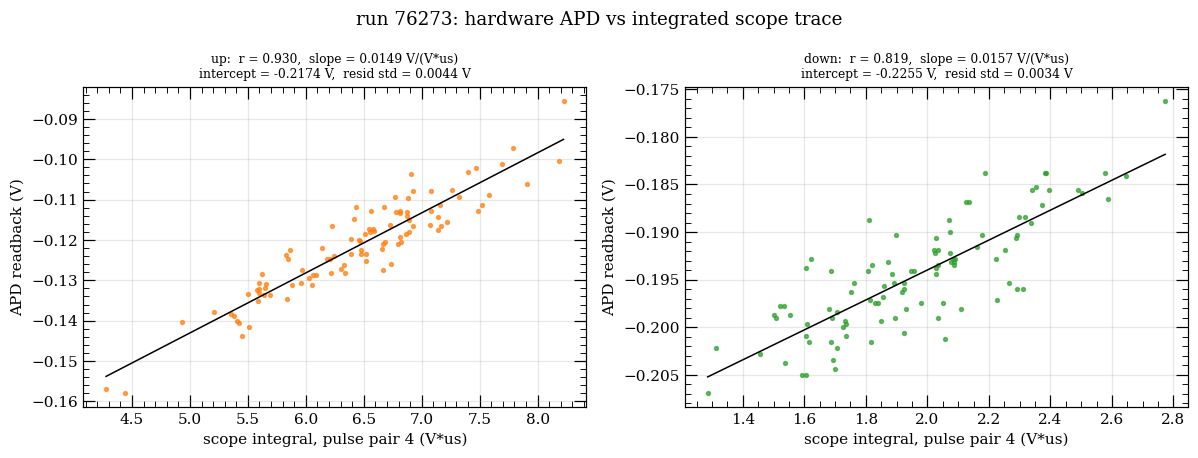

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, (x, y, spin, c) in zip(axes, [(last_even, apd_even, SPIN_EVEN, 'C1'),
                                      (last_odd,  apd_odd,  SPIN_ODD,  'C2')]):
    ax.plot(x, y, '.', ms=5, color=c, alpha=0.7)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() > 2 and np.std(x[ok]) > 0:
        slope, icpt = np.polyfit(x[ok], y[ok], 1)
        r = np.corrcoef(x[ok], y[ok])[0, 1]
        xs = np.linspace(x[ok].min(), x[ok].max(), 2)
        ax.plot(xs, slope*xs + icpt, 'k-', lw=1)
        resid = y[ok] - (slope*x[ok] + icpt)
        ax.set_title(f'{spin}:  r = {r:.3f},  slope = {slope:.4f} V/(V*us)\n'
                     f'intercept = {icpt:.4f} V,  '
                     f'resid std = {resid.std(ddof=1):.4f} V', fontsize=8)
        print(f'  {spin:<6s} r = {r:+.4f}   slope = {slope:.5f} V/(V*us)   '
              f'intercept = {icpt:+.5f} V   resid std = {resid.std(ddof=1):.5f} V '
              f'({100*resid.std(ddof=1)/abs(y[ok].mean()):.2f} % of the mean)')
    ax.set_xlabel(f'scope integral, pulse pair {n_pairs_all-1} (V*us)')
    ax.set_ylabel('APD readback (V)')

fig.suptitle(f'run {ad.run_info.run_id}: hardware APD vs integrated scope trace')
fig.tight_layout()

## Summary

In [ ]:
print(f'run {ad.run_info.run_id}   {n_shots} shots x {n_pairs} of '
      f'{n_pairs_all} {SPIN_EVEN}/{SPIN_ODD} pulse pairs (pulses {pulse_idx[0]}..{pulse_idx[-1]})   '
      f'START_AT_NTH_PULSE = {P0}, N_FIRST = {N}\n')

print('within-shot (over the pulses of one shot, mean over shots)')
if WITHIN_OK:
    print(f'  {SPIN_EVEN:<12s} raw {np.std(S_even, 1, ddof=1).mean():8.4f} V*us  '
          f'detrended {np.std(S_even_dt, 1, ddof=1).mean():8.4f} V*us  '
          f'({100*np.std(S_even_dt, 1, ddof=1).mean()/abs(S_even.mean()):5.2f} %)')
    print(f'  {SPIN_ODD:<12s} raw {np.std(S_odd, 1, ddof=1).mean():8.4f} V*us  '
          f'detrended {np.std(S_odd_dt, 1, ddof=1).mean():8.4f} V*us  '
          f'({100*np.std(S_odd_dt, 1, ddof=1).mean()/abs(S_odd.mean()):5.2f} %)')
    print(f'  contrast     raw {np.std(C_pair, 1, ddof=1).mean():8.4f}       '
          f'detrended {np.std(detrend_by_pulse_index(C_pair), 1, ddof=1).mean():8.4f}')
else:
    print(f'  not measurable -- only {n_pairs} pulse pair retained '
          f'(START_AT_NTH_PULSE = {P0})')

print(f'\nacross-shot, scope, mean over the first {N} retained pulses ({span})')
summarize(f'{SPIN_EVEN}', even_N, 'V*us')
summarize(f'{SPIN_ODD}', odd_N, 'V*us')
summarize('difference', diff_N, 'V*us')
summarize('contrast', cont_N)

print(f'\nacross-shot, APD, loop iteration {n_pairs_all-1}')
summarize(f'{SPIN_EVEN}', apd_even, 'V')
summarize(f'{SPIN_ODD}', apd_odd, 'V')
summarize('difference', apd_even - apd_odd, 'V')
summarize('contrast', contrast(apd_even, apd_odd))

sn = ('yes' if sd_even[-1] < 0.75 * sd_even[0]
      else 'no -- a common per-shot offset dominates')
print(f'\naveraging pulses reduces the across-shot scatter: {sn}')

run 76273   100 shots x 4 of 5 up/down pulse pairs (pulses 1..4)   START_AT_NTH_PULSE = 1, N_FIRST = 3

within-shot (over the pulses of one shot, mean over shots)
  up           raw   0.5495 V*us  detrended   0.4946 V*us  ( 7.29 %)
  down         raw   0.4815 V*us  detrended   0.4496 V*us  (25.34 %)
  contrast     raw   0.0894       detrended   0.0784

across-shot, scope, mean over the first 3 retained pulses (pulses 1..3)
  up                                     6.9047 +/-   1.0268 V*us   ( 14.87 %)
  down                                   1.7108 +/-   0.4842 V*us   ( 28.30 %)
  difference                             5.1939 +/-   0.7358 V*us   ( 14.17 %)
  contrast                               0.6081 +/-   0.0660        ( 10.85 %)

across-shot, APD, loop iteration 4
  up                                    -0.1216 +/-   0.0120 V      (  9.84 %)
  down                                  -0.1945 +/-   0.0059 V      (  3.01 %)
  difference                             0.0729 +/-   0.0139 V 